In [2]:
!pip3 install jupyter pandas numpy matplotlib pillow

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
import os
print(os.path.expanduser("~"))

/Users/rajpadhi


In [8]:
dataset_path = "/Users/rajpadhi/Desktop/train"

In [10]:
import os

print(os.listdir(dataset_path))

['.DS_Store', 'polymer-non-branded', 'polymer-branded', 'keypad-non-branded', 'others', 'keypad-branded']


In [14]:
class_counts = {}

for cls in sorted(os.listdir(dataset_path)):

    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):

        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(
                (".jpg",".jpeg",".png")
            )
        ])

        class_counts[cls] = count

class_counts

{'keypad-branded': 5004,
 'keypad-non-branded': 5015,
 'others': 2564,
 'polymer-branded': 2547,
 'polymer-non-branded': 2501}

In [16]:
total = sum(class_counts.values())

print("Total Images:", total)

Total Images: 17631


In [18]:
import pandas as pd

df = pd.DataFrame(
    class_counts.items(),
    columns=["Class","Images"]
)

df

,Class,Images
0,keypad-branded,5004
1,keypad-non-branded,5015
2,others,2564
3,polymer-branded,2547
4,polymer-non-branded,2501


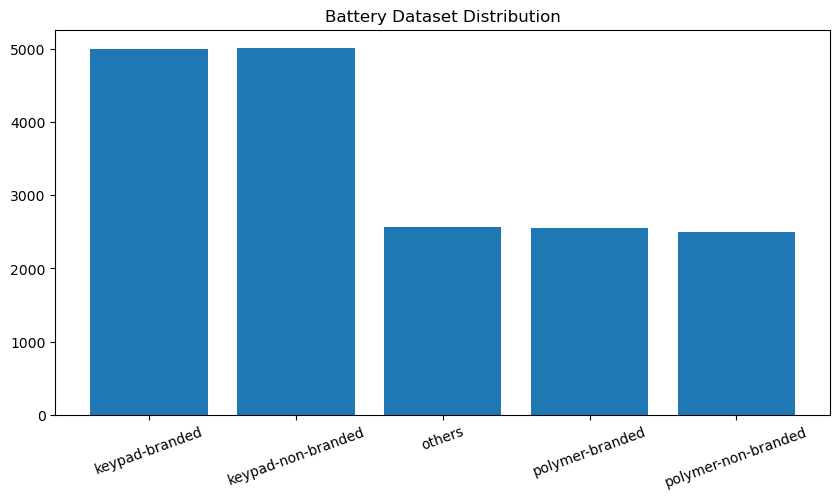

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xticks(rotation=20)

plt.title("Battery Dataset Distribution")

plt.show()

(2448, 2048)


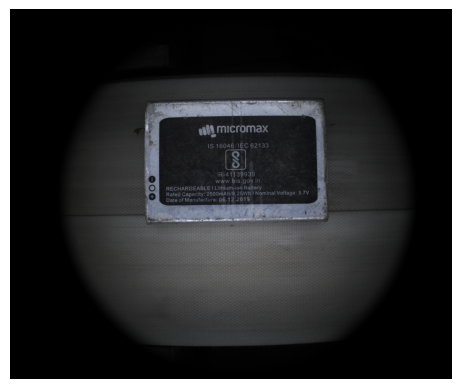

In [28]:
from PIL import Image
import matplotlib.pyplot as plt
import os

folder = os.path.join(
    dataset_path,
    "keypad-branded"
)

img_name = os.listdir(folder)[0]

img_path = os.path.join(folder, img_name)

img = Image.open(img_path)

print(img.size)

plt.imshow(img)
plt.axis("off")
plt.show()

In [26]:
from PIL import Image
import os

bad_images = []
checked = 0

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith(
            ('.jpg','.jpeg','.png')
        ):

            checked += 1

            if checked % 1000 == 0:
                print("Checked:", checked)

            path = os.path.join(root,file)

            try:
                with Image.open(path) as img:
                    img.verify()

            except:
                bad_images.append(path)

print("Bad Images:", len(bad_images))

Checked: 1000
Checked: 2000
Checked: 3000
Checked: 4000
Checked: 5000
Checked: 6000
Checked: 7000
Checked: 8000
Checked: 9000
Checked: 10000
Checked: 11000
Checked: 12000
Checked: 13000
Checked: 14000
Checked: 15000
Checked: 16000
Checked: 17000
Bad Images: 0


In [32]:
from PIL import Image
import os

widths = []
heights = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith(
            ('.jpg','.jpeg','.png')
        ):

            path = os.path.join(root,file)

            with Image.open(path) as img:

                w, h = img.size

                widths.append(w)
                heights.append(h)

print("Min Width :", min(widths))
print("Max Width :", max(widths))

print("Min Height:", min(heights))
print("Max Height:", max(heights))

Min Width : 2448
Max Width : 2448
Min Height: 2048
Max Height: 2048


In [34]:
unique_sizes = set()

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith(
            ('.jpg','.jpeg','.png')
        ):

            path = os.path.join(root,file)

            with Image.open(path) as img:

                unique_sizes.add(img.size)

print("Number of unique sizes:", len(unique_sizes))

print(unique_sizes)

Number of unique sizes: 1
{(2448, 2048)}


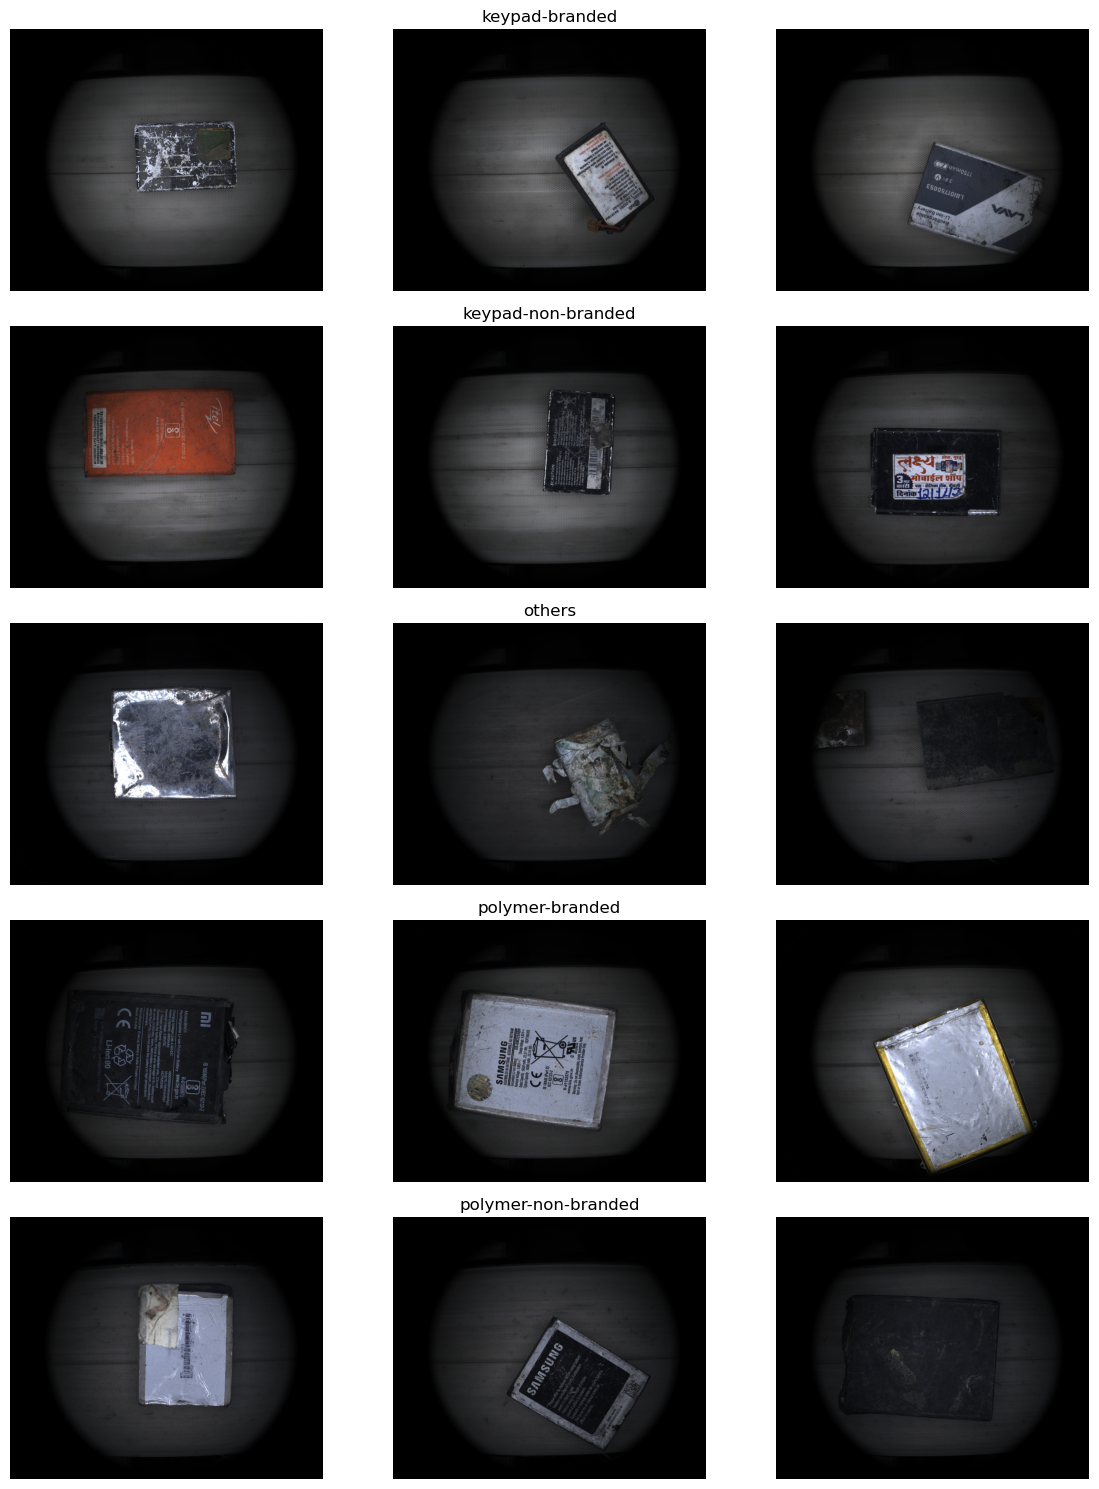

In [38]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

classes = [
    c for c in sorted(os.listdir(dataset_path))
    if os.path.isdir(os.path.join(dataset_path, c))
]

fig, axes = plt.subplots(len(classes), 3, figsize=(12,15))

for i, cls in enumerate(classes):

    cls_path = os.path.join(dataset_path, cls)

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    samples = random.sample(images, min(3, len(images)))

    for j, img_name in enumerate(samples):

        img_path = os.path.join(cls_path, img_name)

        img = Image.open(img_path)

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        if j == 1:
            axes[i, j].set_title(cls)

plt.tight_layout()
plt.show()